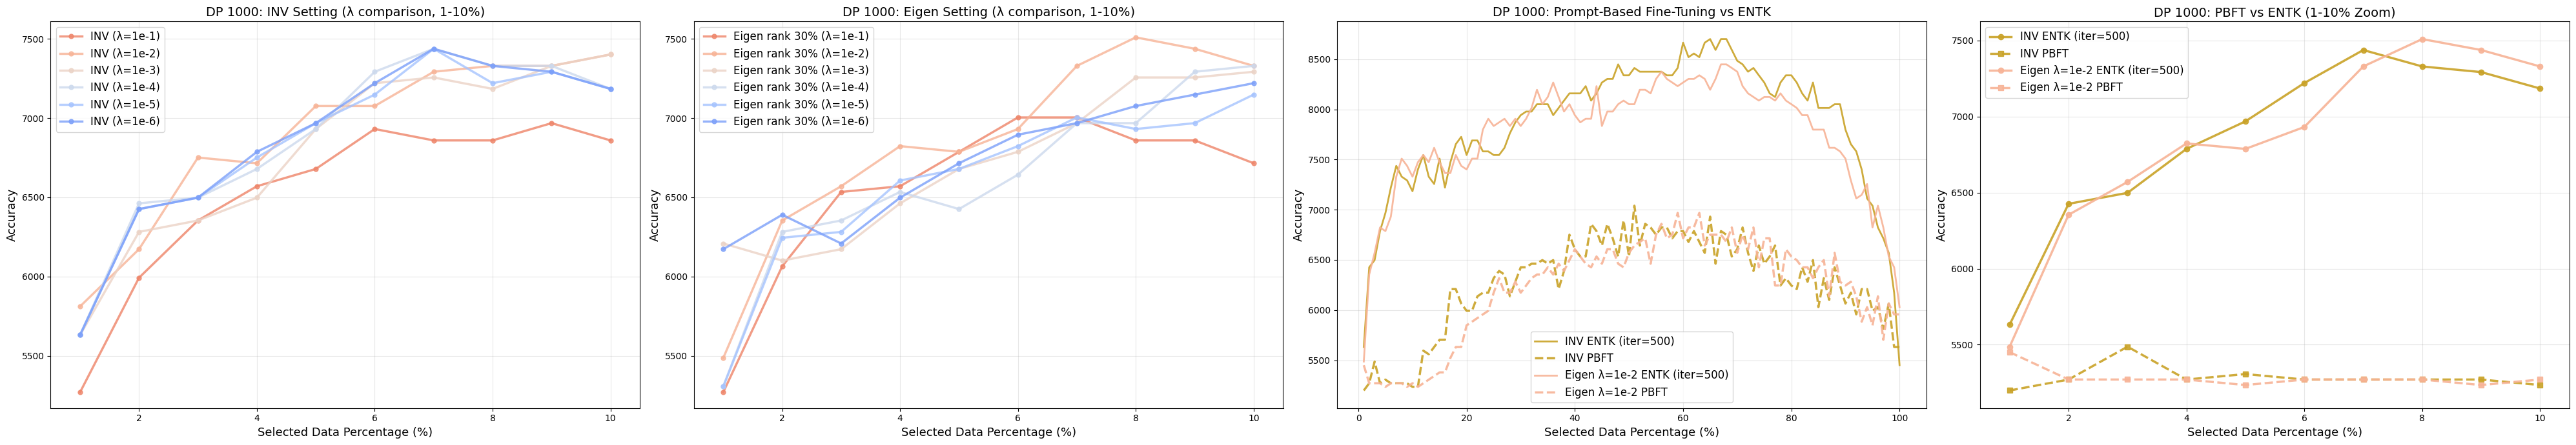

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [5632, 6426, 6498, 6787, 6968, 7220, 7437, 7329, 7292, 7184, 7401, 7545, 7329, 7256, 7509, 7220, 7473, 7653, 7726, 7545, 7690, 7690, 7581, 7581, 7545, 7545, 7617, 7762, 7870, 7942, 7978, 7978, 8051, 8051, 8051, 7942, 8014, 8087, 8159, 8159, 8159, 8231, 8087, 8159, 8267, 8303, 8303, 8448, 8339, 8339, 8412, 8375, 8375, 8375, 8375, 8375, 8339, 8339, 8412, 8664, 8520, 8556, 8520, 8664, 8700, 8592, 8700, 8700, 8592, 8484, 8448, 8375, 8412, 8339, 8267, 8159, 8123, 8267, 8339, 8339, 8267, 8159, 8087, 8267, 8014, 8014, 8014, 8051, 8051, 7798, 7653, 7581, 7401, 7112, 7040, 6823, 6715, 6570, 6173, 5451]
inv_lam1e_5      = [5632, 6426, 6498, 6751, 6968, 7148, 7437, 7220, 7292, 7184, 7365, 7473, 7329, 7256, 7329, 7220, 7401, 7653, 7653, 7545, 7690, 7653, 7617, 7509, 7545, 7617, 7617, 7870, 7942, 7870, 7978, 8014, 7942, 8014, 8051, 8014, 8051, 8051, 8195, 8159, 8123, 8159, 8123, 8195, 8195, 8303, 8303, 8412, 8339, 8303, 8448, 8375, 8339, 8339, 8339, 8375, 8339, 8303, 8448, 8556, 8628, 8556, 8736, 8556, 8700, 8809, 8773, 8664, 8592, 8592, 8412, 8375, 8412, 8303, 8159, 8159, 8123, 8267, 8339, 8339, 8267, 8195, 8051, 8267, 7942, 8014, 8051, 8123, 8051, 7798, 7653, 7437, 7401, 7112, 7040, 6823, 6715, 6570, 6173, 5451]   
inv_lam1e_4      = [5632, 6462, 6498, 6679, 6931, 7292, 7437, 7329, 7329, 7184, 7401, 7509, 7329, 7256, 7365, 7329, 7329, 7437, 7653, 7690, 7690, 7653, 7581, 7545, 7545, 7690, 7870, 7834, 7870, 7834, 7906, 7942, 8051, 7978, 8014, 7978, 8014, 8159, 8123, 8123, 8123, 8087, 8087, 8159, 8231, 8303, 8303, 8303, 8303, 8303, 8484, 8412, 8303, 8303, 8303, 8303, 8303, 8231, 8375, 8412, 8700, 8628, 8592, 8628, 8664, 8664, 8664, 8700, 8592, 8520, 8448, 8412, 8412, 8267, 8267, 8195, 8231, 8339, 8412, 8339, 8339, 8195, 8159, 8195, 8051, 8051, 7978, 8051, 8051, 7726, 7617, 7509, 7401, 7184, 7148, 6715, 6679, 6462, 6173, 5451] 
inv_lam1e_3      = [5632, 6282, 6354, 6498, 6931, 7220, 7256, 7184, 7329, 7401, 7401, 7329, 7220, 7329, 7365, 7437, 7545, 7509, 7437, 7545, 7653, 7545, 7473, 7617, 7653, 7581, 7581, 7617, 7690, 7906, 7942, 8051, 8087, 8087, 8051, 7978, 7978, 8087, 8087, 8014, 8159, 8087, 8123, 8087, 8087, 8087, 8195, 8231, 8303, 8231, 8339, 8231, 8303, 8303, 8339, 8231, 8303, 8412, 8556, 8375, 8412, 8412, 8412, 8556, 8592, 8664, 8664, 8592, 8556, 8484, 8484, 8339, 8159, 8231, 8195, 8231, 8231, 8267, 8267, 8375, 8339, 8303, 8195, 8195, 8051, 8123, 8123, 8014, 7942, 7834, 7762, 7653, 7365, 7220, 7004, 6715, 6643, 6498, 6029, 5451] 
inv_lam1e_2      = [5812, 6173, 6751, 6715, 7076, 7076, 7292, 7329, 7329, 7401, 7329, 7365, 7329, 7256, 7473, 7401, 7545, 7401, 7581, 7545, 7581, 7617, 7653, 7726, 7653, 7653, 7581, 7581, 7690, 7617, 7653, 7870, 7798, 7798, 7798, 7870, 7942, 7978, 8014, 8051, 8087, 8123, 8087, 8123, 8159, 8123, 8231, 8087, 8231, 8231, 8339, 8412, 8303, 8339, 8375, 8303, 8267, 8267, 8267, 8303, 8303, 8412, 8339, 8412, 8339, 8375, 8375, 8267, 8267, 8303, 8412, 8412, 8412, 8520, 8412, 8375, 8375, 8231, 8159, 7978, 8159, 8159, 8087, 8123, 8123, 8051, 8087, 8014, 7978, 7834, 7690, 7653, 7509, 7076, 7004, 6751, 6823, 6534, 6173, 5632] 
inv_lam1e_1      = [5271, 5993, 6354, 6570, 6679, 6931, 6859, 6859, 6968, 6859, 6968, 7040, 7148, 7365, 7292, 7365, 7256, 7112, 7292, 7401, 7184, 7256, 7220, 7220, 7256, 7437, 7329, 7256, 7256, 7292, 7401, 7473, 7437, 7545, 7653, 7690, 7617, 7653, 7690, 7690, 7617, 7762, 7798, 7798, 7798, 7978, 7906, 7906, 7942, 7942, 8014, 8123, 8087, 8123, 8159, 8087, 8123, 8051, 8051, 8123, 8051, 8195, 8159, 8195, 8303, 8267, 8195, 8195, 8051, 8014, 8123, 8051, 8231, 8375, 8412, 8339, 8303, 8339, 8339, 8267, 8087, 7978, 7942, 7978, 8014, 7834, 7762, 7834, 7870, 7653, 7509, 7401, 7148, 6968, 7004, 6931, 6643, 6426, 6245, 5487]  
eigen_lam1e_6    = [6173, 6390, 6209, 6498, 6715, 6895, 6968, 7076, 7148, 7220, 7292, 7545, 7617, 7617, 7653, 7329, 7473, 7256, 7040, 7148, 6968, 7004, 7040, 7220, 7148, 6968, 6931, 6643, 6426, 5704, 6318, 6498, 6823, 6931, 7256, 7292, 7292, 7437, 7690, 7726, 7906, 7870, 7870, 7726, 7906, 7906, 7870, 7798, 7617, 7690, 7581, 7834, 7834, 7906, 7834, 7942, 7978, 8087, 8051, 7978, 7906, 7834, 7870, 7834, 7834, 7762, 7762, 7690, 8087, 7978, 7942, 8087, 7906, 8051, 7978, 7870, 7798, 7762, 7870, 7870, 7762, 7653, 7509, 7617, 7762, 7906, 7617, 7509, 7437, 7329, 7329, 7292, 7256, 7292, 7004, 7076, 6859, 6679, 6606, 6029]
eigen_lam1e_5    = [5307, 6245, 6282, 6606, 6679, 6823, 7004, 6931, 6968, 7148, 7256, 7365, 7329, 7437, 7581, 7762, 7581, 7473, 7545, 7401, 7148, 7076, 7112, 7184, 6823, 7148, 7112, 6751, 6354, 6426, 6462, 6606, 6570, 6282, 6895, 7004, 6931, 7184, 7220, 7256, 7653, 7798, 8087, 7906, 7978, 8159, 8159, 8087, 7942, 8051, 7942, 7978, 8123, 8267, 8087, 8123, 8159, 8087, 8051, 8051, 8231, 8159, 8303, 8051, 7942, 7906, 7906, 7942, 7870, 7798, 8087, 8051, 7978, 7870, 7978, 7942, 7906, 7798, 7834, 7726, 7690, 7870, 7726, 7870, 7617, 7509, 7690, 7617, 7473, 7473, 7256, 7256, 7184, 6895, 7004, 6787, 6787, 6643, 6462, 6029]
eigen_lam1e_4    = [5307, 6282, 6354, 6534, 6426, 6643, 6968, 6968, 7292, 7329, 7220, 7256, 7220, 7437, 7509, 7437, 7401, 7545, 7437, 7617, 7545, 7509, 7545, 7762, 7545, 7473, 7148, 6931, 6679, 6606, 6679, 6751, 6859, 6931, 7653, 7762, 7762, 7726, 7834, 7906, 7942, 8014, 7906, 8051, 8123, 8051, 8159, 8159, 8339, 8159, 8123, 8195, 8195, 8267, 8231, 8267, 8195, 8195, 8231, 8267, 8159, 7942, 7870, 7762, 7834, 7942, 7906, 7942, 7726, 7798, 7906, 7978, 7870, 7906, 7834, 7906, 7906, 7942, 7834, 7942, 7798, 7834, 7653, 7762, 7942, 7762, 7762, 7473, 7437, 7473, 7401, 7401, 7112, 7076, 7076, 6931, 7112, 6643, 6426, 6029]
eigen_lam1e_3    = [6209, 6101, 6173, 6462, 6679, 6787, 6968, 7256, 7256, 7292, 7365, 7581, 7401, 7401, 7473, 7581, 7726, 7690, 7653, 7762, 7798, 7726, 7653, 7653, 7437, 7509, 7473, 7473, 7798, 7509, 7653, 7870, 7690, 7762, 7906, 8014, 8123, 8087, 8231, 8123, 8231, 8195, 8267, 8051, 8087, 8159, 8195, 8231, 8195, 8051, 8014, 7978, 8195, 8051, 7978, 7906, 7978, 7978, 7978, 8159, 8051, 8087, 7942, 7834, 8051, 8087, 8123, 8231, 8087, 8303, 8195, 8339, 8303, 8231, 8339, 8267, 8231, 8051, 8123, 8087, 7870, 7906, 7834, 7906, 7798, 7726, 7798, 7726, 7653, 7509, 7437, 7148, 7004, 6931, 6968, 7040, 6823, 6643, 6426, 5993]
eigen_lam1e_2    = [5487, 6354, 6570, 6823, 6787, 6931, 7329, 7509, 7437, 7329, 7473, 7545, 7473, 7617, 7473, 7365, 7365, 7545, 7437, 7401, 7509, 7509, 7798, 7906, 7834, 7870, 7906, 7834, 7906, 7834, 7906, 8014, 8195, 8051, 8123, 8267, 8123, 7978, 8051, 7942, 7870, 7906, 7906, 8231, 7834, 7978, 7978, 8051, 8087, 8051, 8051, 8195, 8195, 8159, 8303, 8375, 8303, 8267, 8231, 8267, 8303, 8303, 8339, 8303, 8195, 8303, 8448, 8448, 8412, 8375, 8231, 8159, 8123, 8087, 8123, 8123, 8087, 8159, 8087, 8051, 8014, 7942, 7942, 7798, 7798, 7798, 7617, 7617, 7581, 7509, 7292, 7112, 7148, 7256, 6823, 7040, 6823, 6534, 6426, 6029]
eigen_lam1e_1    = [5271, 6065, 6534, 6570, 6787, 7004, 7004, 6859, 6859, 6715, 6823, 6859, 6823, 6859, 6931, 6895, 6968, 6859, 7076, 7076, 7184, 7365, 7437, 7437, 7365, 7329, 7401, 7509, 7509, 7617, 7653, 7690, 7545, 7690, 7798, 7762, 7762, 7653, 7798, 7726, 7726, 7690, 7762, 7690, 7690, 7653, 7690, 7653, 7690, 7762, 7690, 7726, 7653, 7581, 7690, 7762, 7762, 7834, 7906, 7870, 7978, 8087, 8051, 8014, 8051, 8051, 8051, 8051, 8231, 8159, 8087, 8014, 8195, 8123, 8159, 8051, 8014, 7942, 8087, 8123, 8231, 8123, 8014, 7870, 7834, 7726, 7509, 7617, 7256, 7329, 7292, 7292, 7112, 6787, 6787, 6787, 6715, 6570, 6318, 6137]

# Prediction with random shapley values
r_inv_lam1e_6     = [5379, 5090, 4765, 4874, 4982, 5054, 5199, 5235, 5126, 4838, 4982, 4982, 5126, 5090, 5090, 5018, 5126, 4946, 4982, 4982, 4982, 5235, 5018, 5235, 5162, 5199, 5199, 5271, 5343, 5415, 5596, 5740, 5596, 5704, 5668, 5343, 5523, 5415, 5704, 5632, 5957, 5884, 5993, 5812, 5921, 5668, 5740, 5993, 5812, 5596, 5632, 5487, 5451, 5379, 5487, 5451, 5560, 5632, 5560, 5523, 5523, 5415, 5596, 5596, 5560, 5523, 5596, 5523, 5379, 5343, 5451, 5704, 5487, 5451, 5487, 5487, 5451, 5379, 5523, 5343, 5523, 5487, 5451, 5523, 5451, 5379, 5379, 5451, 5487, 5523, 5704, 5632, 5812, 5596, 5596, 5704, 5776, 5632, 5596, 5451]
r_inv_lam1e_5     = [5379, 5090, 4765, 4874, 4982, 5054, 5199, 5235, 5126, 4838, 4982, 4982, 5126, 5090, 5090, 5018, 5126, 4946, 4982, 4982, 4982, 5235, 5018, 5235, 5162, 5199, 5199, 5271, 5343, 5415, 5596, 5740, 5596, 5704, 5668, 5343, 5523, 5415, 5704, 5632, 5957, 5884, 5993, 5812, 5921, 5668, 5740, 5993, 5812, 5596, 5632, 5487, 5451, 5379, 5487, 5451, 5560, 5632, 5560, 5523, 5523, 5415, 5596, 5596, 5560, 5523, 5596, 5523, 5379, 5343, 5451, 5704, 5487, 5451, 5487, 5487, 5451, 5379, 5523, 5343, 5523, 5487, 5451, 5523, 5451, 5379, 5379, 5451, 5487, 5523, 5704, 5632, 5812, 5596, 5596, 5704, 5776, 5632, 5596, 5451]
r_inv_lam1e_4     = [5379, 5090, 4765, 4874, 4982, 5054, 5199, 5235, 5126, 4838, 4982, 4982, 5126, 5090, 5090, 5018, 5126, 4946, 4982, 4982, 4982, 5235, 5018, 5235, 5162, 5199, 5199, 5271, 5343, 5415, 5596, 5740, 5596, 5704, 5668, 5343, 5523, 5415, 5740, 5632, 5957, 5848, 5993, 5812, 5921, 5668, 5740, 5993, 5812, 5596, 5632, 5487, 5451, 5379, 5523, 5451, 5560, 5632, 5560, 5523, 5523, 5415, 5596, 5596, 5560, 5523, 5596, 5523, 5379, 5343, 5451, 5704, 5487, 5451, 5487, 5487, 5451, 5379, 5523, 5343, 5523, 5487, 5451, 5523, 5451, 5379, 5379, 5451, 5487, 5523, 5704, 5668, 5812, 5596, 5596, 5704, 5776, 5632, 5596, 5451]
r_inv_lam1e_3     = [5379, 5090, 4765, 4874, 4982, 5054, 5199, 5235, 5162, 4838, 4982, 4982, 5126, 5090, 5090, 4982, 5090, 4946, 4982, 4982, 4982, 5235, 5018, 5235, 5162, 5199, 5199, 5271, 5343, 5415, 5596, 5740, 5596, 5704, 5704, 5343, 5523, 5415, 5740, 5632, 5993, 5848, 6029, 5812, 5957, 5668, 5740, 6029, 5812, 5596, 5668, 5487, 5487, 5379, 5523, 5451, 5560, 5632, 5596, 5523, 5523, 5415, 5596, 5596, 5560, 5523, 5596, 5523, 5379, 5343, 5451, 5704, 5487, 5415, 5487, 5487, 5451, 5415, 5523, 5343, 5451, 5487, 5451, 5523, 5451, 5379, 5379, 5451, 5523, 5523, 5704, 5668, 5848, 5596, 5632, 5704, 5776, 5596, 5560, 5451]
r_inv_lam1e_2     = [5379, 5054, 4874, 4838, 4982, 5018, 5199, 5235, 5126, 4910, 4946, 4982, 5162, 5018, 5090, 5018, 5018, 5018, 4982, 4946, 4982, 5199, 5018, 5235, 5162, 5162, 5199, 5307, 5451, 5415, 5596, 5884, 5632, 5776, 5740, 5379, 5523, 5415, 5704, 5704, 6101, 5884, 6029, 5884, 5993, 5668, 5740, 6065, 5812, 5596, 5632, 5487, 5451, 5415, 5487, 5451, 5560, 5523, 5523, 5523, 5523, 5487, 5632, 5632, 5596, 5596, 5560, 5523, 5343, 5415, 5487, 5632, 5560, 5487, 5596, 5523, 5451, 5415, 5560, 5343, 5343, 5487, 5451, 5451, 5487, 5487, 5343, 5451, 5523, 5632, 5776, 5668, 5668, 5632, 5704, 5704, 5776, 5632, 5596, 5632] 
r_inv_lam1e_1     = [5415, 4801, 4946, 4874, 4982, 5018, 5126, 5235, 5199, 4946, 5090, 5018, 5054, 5090, 5018, 5054, 5054, 5090, 5090, 5018, 4982, 5271, 5054, 5199, 5307, 5307, 5379, 5343, 5487, 5487, 5632, 5812, 5668, 5921, 5704, 5487, 5596, 5487, 5523, 5632, 6029, 5921, 5993, 5921, 5848, 5812, 5921, 5921, 5776, 5704, 5740, 5596, 5596, 5632, 5596, 5632, 5596, 5704, 5632, 5776, 5884, 5704, 5704, 5596, 5776, 5523, 5632, 5704, 5704, 5848, 5812, 5704, 5523, 5487, 5523, 5596, 5704, 5704, 5704, 5740, 5596, 5560, 5560, 5668, 5704, 5668, 5632, 5523, 5668, 5560, 5704, 5668, 5632, 5596, 5740, 5632, 5812, 5704, 5523, 5487]        
r_eigen_lam1e_6   = [5523, 4838, 4693, 4801, 4801, 4946, 5162, 5162, 5523, 5199, 5090, 4910, 5379, 5415, 5307, 5199, 5235, 5162, 4874, 5126, 4874, 4801, 5018, 4729, 5018, 5199, 5379, 5162, 4910, 5271, 5054, 5162, 4838, 4910, 5379, 5343, 5235, 5343, 5090, 5668, 5271, 5271, 5523, 5415, 5379, 5379, 5776, 5704, 5596, 5668, 5523, 5632, 5451, 5740, 5884, 5957, 5740, 5993, 6029, 5993, 6065, 6029, 5993, 5884, 5812, 5884, 6029, 5921, 5921, 5921, 5921, 5993, 5921, 5848, 5957, 5884, 5957, 6065, 5993, 5776, 5812, 6209, 5884, 6065, 5921, 5848, 5668, 5668, 5812, 5848, 6029, 6101, 6065, 6029, 6101, 6029, 6101, 6282, 6101, 6029]
r_eigen_lam1e_5   = [5451, 4838, 4693, 4765, 4838, 5018, 5162, 5199, 5451, 5162, 5162, 4910, 5415, 5415, 5271, 5162, 5199, 5235, 4982, 5199, 4838, 4874, 5162, 4801, 5018, 5235, 5379, 5162, 4946, 5054, 5199, 5162, 4838, 4910, 5379, 5343, 5235, 5343, 5090, 5704, 5271, 5271, 5523, 5415, 5379, 5379, 5776, 5704, 5596, 5668, 5523, 5632, 5451, 5740, 5884, 5957, 5740, 5993, 6065, 5993, 6065, 6029, 5993, 5884, 5812, 5884, 6029, 5921, 5921, 5921, 5921, 5993, 5921, 5848, 5957, 5884, 5957, 6065, 5993, 5776, 5812, 6209, 5884, 6065, 5921, 5848, 5668, 5668, 5812, 5848, 6029, 6101, 6065, 6029, 6101, 6029, 6101, 6282, 6101, 6029]
r_eigen_lam1e_4   = [5451, 4838, 4657, 4765, 4838, 5018, 5162, 5199, 5451, 5162, 5162, 4946, 5379, 5415, 5271, 5199, 5199, 5271, 4982, 5235, 4838, 4838, 5199, 4765, 5126, 5235, 5379, 5090, 5054, 5054, 5162, 5343, 4982, 4874, 5343, 5271, 5235, 5343, 5054, 5704, 5307, 5271, 5487, 5451, 5451, 5415, 5776, 5704, 5596, 5668, 5523, 5668, 5451, 5740, 5884, 5957, 5740, 5993, 6065, 5993, 6065, 6029, 5993, 5884, 5812, 5884, 6029, 5921, 5921, 5921, 5921, 5957, 5921, 5848, 5957, 5884, 5957, 6065, 5993, 5776, 5812, 6209, 5884, 6065, 5921, 5848, 5668, 5668, 5812, 5848, 6029, 6101, 6065, 6029, 6101, 6029, 6101, 6282, 6101, 6029]
r_eigen_lam1e_3   = [5451, 4910, 4657, 4729, 4838, 4982, 5162, 5162, 5451, 5235, 5090, 4946, 5379, 5451, 5307, 5343, 5343, 5343, 4838, 5162, 4838, 4838, 5090, 4693, 5199, 5235, 5379, 5018, 5018, 4946, 5054, 5307, 5054, 5235, 5271, 5343, 5343, 5307, 5162, 5740, 5307, 5415, 5523, 5523, 5415, 5379, 5812, 5668, 5560, 5704, 5523, 5632, 5451, 5704, 5884, 5957, 5704, 5993, 6029, 5993, 6029, 6065, 5993, 5921, 5848, 5921, 6029, 5921, 5957, 5921, 5921, 5957, 5884, 5884, 5957, 5884, 5957, 6065, 5993, 5776, 5812, 6209, 5884, 6065, 5921, 5848, 5668, 5668, 5812, 5848, 6029, 6101, 6065, 6029, 6101, 6029, 6101, 6282, 6101, 5993]
r_eigen_lam1e_2   = [5451, 4946, 4729, 4657, 4729, 4874, 5235, 5126, 5343, 5199, 5090, 5090, 5596, 5487, 5343, 5271, 5162, 5379, 4982, 5235, 4838, 4982, 5090, 5018, 5343, 5235, 5487, 5054, 5235, 5271, 5704, 5415, 5487, 5487, 5704, 5704, 5523, 5343, 5560, 5812, 5848, 5704, 5776, 5812, 5632, 5668, 5848, 5668, 5560, 5668, 5704, 5632, 5560, 5632, 5884, 5884, 5884, 6065, 5884, 5993, 6137, 5957, 6065, 5884, 5921, 5921, 6029, 5884, 5993, 5993, 5957, 6029, 5848, 5812, 5957, 5957, 5993, 6029, 6101, 5776, 5848, 6245, 5921, 6065, 5921, 5848, 5596, 5668, 5921, 5812, 6029, 6029, 6065, 6029, 6101, 6029, 6101, 6245, 6173, 6029]
r_eigen_lam1e_1   = [5343, 4801, 4729, 4765, 4874, 5054, 5307, 5415, 5271, 4910, 4874, 4729, 4910, 4729, 4946, 4838, 4946, 5162, 4982, 5054, 4874, 5126, 5054, 5162, 5523, 5379, 5596, 5560, 5487, 5704, 5776, 5776, 5668, 5632, 5523, 5704, 5632, 5704, 5812, 5993, 6101, 5776, 5957, 5884, 5993, 5812, 5993, 5812, 5740, 5957, 5848, 5848, 5812, 5740, 6029, 6029, 5848, 5884, 6101, 6101, 6101, 5957, 6029, 5957, 6065, 6137, 6282, 6137, 6245, 6137, 5993, 6065, 6173, 6065, 6137, 6029, 5957, 5921, 6065, 5957, 5957, 5993, 5921, 5812, 5957, 5812, 5776, 5596, 5884, 5884, 5993, 6065, 5993, 5993, 5921, 5993, 6065, 6245, 6065, 6137]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [5199, 5271, 5487, 5271, 5307, 5271, 5271, 5271, 5271, 5235, 5235, 5596, 5560, 5632, 5704, 5704, 6209, 6209, 6065, 5993, 5993, 6137, 6173, 6173, 6318, 6390, 6354, 6137, 6282, 6426, 6426, 6462, 6462, 6498, 6462, 6498, 6209, 6390, 6751, 6606, 6534, 6534, 6859, 6787, 6643, 6859, 6715, 6534, 6895, 6534, 7040, 6643, 6859, 6823, 6751, 6823, 6823, 6715, 6787, 6787, 6679, 6787, 6679, 6570, 6931, 6462, 6787, 6751, 6534, 6606, 6823, 6570, 6390, 6643, 6462, 6534, 6643, 6245, 6318, 6245, 6209, 6426, 6282, 6498, 6029, 6318, 6101, 6426, 6245, 6065, 6173, 5957, 6209, 6209, 5993, 6029, 5812, 6065, 5632, 5632]
pbft_eigen_lam1e_2 = [5451, 5271, 5271, 5271, 5235, 5271, 5271, 5271, 5235, 5271, 5235, 5271, 5307, 5343, 5379, 5379, 5523, 5632, 5632, 5848, 5884, 5921, 5957, 5993, 6173, 6318, 6173, 6173, 6282, 6173, 6245, 6318, 6354, 6354, 6426, 6354, 6462, 6390, 6498, 6606, 6534, 6462, 6426, 6534, 6462, 6606, 6606, 6462, 6426, 6570, 6643, 6679, 6715, 6462, 6751, 6859, 6715, 6751, 6968, 6715, 6823, 6823, 6968, 6643, 6751, 6751, 6751, 6679, 6823, 6570, 6751, 6606, 6823, 6426, 6715, 6715, 6245, 6245, 6606, 6534, 6498, 6426, 6426, 6318, 6426, 6498, 6137, 6570, 6282, 6245, 6282, 6137, 5884, 6029, 5848, 6137, 5704, 6065, 5957, 5957]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Prepare 1-10% data for comparison
zoom_percent = selected_dp_percent[:10]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# Plot INV with different lambda values (1-10% only)
inv_lambda_data = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

for i, (data, lam_label) in enumerate(inv_lambda_data):
    if data is not None:
        ax_left.plot(zoom_percent, data[:10], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, 10.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Plot Eigen with different lambda values (1-10% only)
eigen_lambda_data = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

for i, (data, lam_label) in enumerate(eigen_lambda_data):
    if data is not None:
        ax_middle.plot(zoom_percent, data[:10], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, 10.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# Set same y-axis range for (1,1) and (1,2)
all_inv_values = [val for data, _ in inv_lambda_data if data is not None for val in data[:10]]
all_eigen_values = [val for data, _ in eigen_lambda_data if data is not None for val in data[:10]]
all_values = all_inv_values + all_eigen_values
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

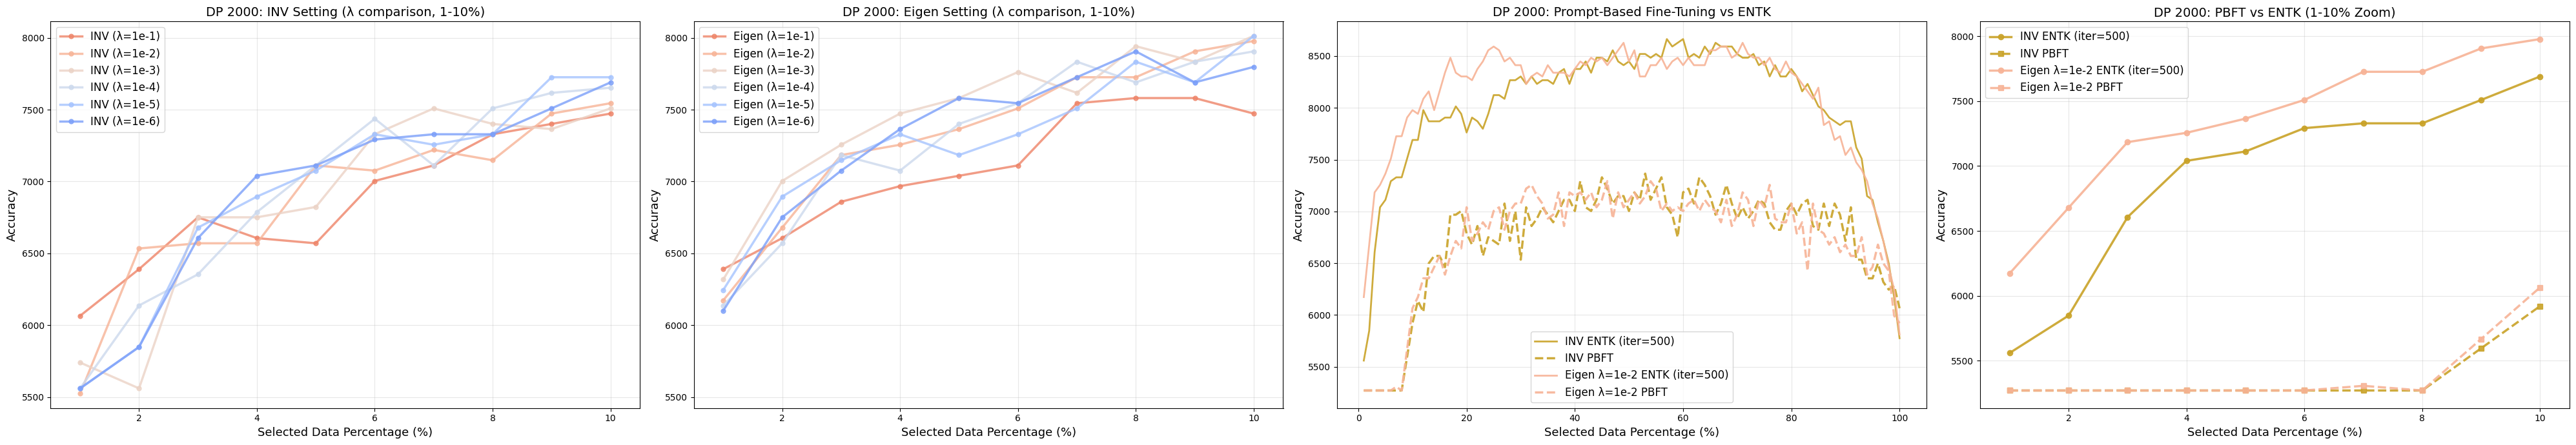

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6     = [5560, 5848, 6606, 7040, 7112, 7292, 7329, 7329, 7509, 7690, 7690, 7978, 7870, 7870, 7870, 7906, 7906, 8014, 7942, 7762, 7906, 7870, 7798, 7942, 8123, 8123, 8087, 8267, 8267, 8303, 8231, 8303, 8231, 8267, 8267, 8231, 8339, 8375, 8231, 8375, 8375, 8448, 8339, 8484, 8484, 8448, 8556, 8448, 8412, 8448, 8375, 8520, 8520, 8484, 8520, 8484, 8664, 8592, 8628, 8664, 8484, 8520, 8484, 8592, 8520, 8628, 8592, 8592, 8592, 8520, 8484, 8484, 8520, 8412, 8448, 8303, 8412, 8303, 8303, 8375, 8303, 8159, 8231, 8123, 8014, 7978, 7906, 7870, 7834, 7870, 7870, 7617, 7509, 7148, 7112, 6895, 6715, 6498, 6173, 5776]
inv_lam1e_5     = [5560, 5848, 6679, 6895, 7076, 7329, 7256, 7329, 7726, 7726, 7798, 7906, 7798, 7798, 7870, 7906, 7978, 7942, 8087, 7798, 7906, 7942, 7978, 8014, 8087, 8087, 8051, 8195, 8231, 8303, 8195, 8303, 8267, 8303, 8231, 8231, 8231, 8267, 8375, 8412, 8412, 8448, 8448, 8484, 8556, 8484, 8339, 8412, 8412, 8375, 8412, 8484, 8556, 8628, 8664, 8628, 8592, 8556, 8556, 8664, 8556, 8484, 8520, 8592, 8592, 8628, 8628, 8556, 8448, 8592, 8484, 8448, 8375, 8339, 8267, 8339, 8339, 8339, 8267, 8412, 8303, 8231, 8267, 8195, 8014, 7978, 7834, 7870, 7834, 7726, 7762, 7726, 7509, 7112, 7040, 6859, 6751, 6426, 6173, 5776]
inv_lam1e_4     = [5560, 6137, 6354, 6787, 7112, 7437, 7112, 7509, 7617, 7653, 7798, 7870, 7978, 7906, 7870, 7978, 7978, 7978, 8014, 7942, 8014, 7942, 8087, 8051, 8159, 8231, 8231, 8303, 8303, 8303, 8195, 8231, 8339, 8267, 8231, 8159, 8159, 8231, 8412, 8339, 8448, 8339, 8412, 8448, 8448, 8556, 8339, 8303, 8448, 8339, 8375, 8412, 8556, 8556, 8592, 8592, 8484, 8520, 8556, 8592, 8520, 8628, 8556, 8592, 8628, 8628, 8520, 8520, 8484, 8484, 8448, 8448, 8375, 8412, 8339, 8448, 8339, 8303, 8339, 8339, 8303, 8303, 8267, 8195, 8195, 7798, 7870, 7834, 7906, 7762, 7726, 7473, 7329, 7220, 6968, 6859, 6643, 6498, 6245, 5740] 
inv_lam1e_3     = [5740, 5560, 6751, 6751, 6823, 7329, 7509, 7401, 7365, 7509, 7762, 7906, 7906, 7942, 7870, 8051, 8159, 8014, 8087, 8195, 8267, 8303, 8159, 8231, 8267, 8375, 8375, 8375, 8339, 8339, 8375, 8448, 8339, 8412, 8375, 8303, 8267, 8267, 8231, 8375, 8375, 8339, 8412, 8412, 8520, 8592, 8484, 8556, 8592, 8448, 8448, 8628, 8520, 8556, 8773, 8773, 8628, 8664, 8700, 8700, 8700, 8773, 8700, 8700, 8628, 8773, 8664, 8736, 8773, 8736, 8664, 8700, 8556, 8628, 8592, 8556, 8484, 8339, 8267, 8195, 8303, 8195, 8123, 8123, 7906, 7906, 7906, 8051, 7870, 7906, 7906, 7690, 7581, 7256, 7184, 7004, 6751, 6390, 6173, 5668]   
inv_lam1e_2     = [5523, 6534, 6570, 6570, 7112, 7076, 7220, 7148, 7473, 7545, 7509, 7690, 8014, 8087, 8123, 8087, 8087, 8159, 8159, 8231, 8159, 8159, 8159, 8159, 8159, 8159, 8159, 8159, 8123, 8123, 8159, 8123, 8195, 8159, 8267, 8303, 8375, 8339, 8231, 8303, 8339, 8303, 8448, 8520, 8556, 8556, 8556, 8520, 8592, 8520, 8628, 8700, 8700, 8664, 8628, 8520, 8484, 8448, 8448, 8448, 8520, 8592, 8592, 8592, 8520, 8628, 8700, 8700, 8664, 8700, 8628, 8628, 8628, 8412, 8412, 8303, 8412, 8448, 8303, 8231, 8195, 8231, 8123, 8014, 8123, 7906, 8014, 7726, 7617, 7726, 7545, 7437, 7329, 7292, 7076, 6931, 6606, 6679, 6137, 5776]   
inv_lam1e_1     = [6065, 6390, 6751, 6606, 6570, 7004, 7112, 7329, 7401, 7473, 7437, 7581, 7509, 7509, 7617, 7726, 7798, 7834, 7942, 7834, 7798, 7726, 7870, 7978, 7906, 7906, 7906, 7978, 7978, 7978, 8014, 7942, 8014, 8087, 8123, 8051, 8123, 8195, 8195, 8087, 8087, 8087, 8123, 8159, 8159, 8267, 8159, 8195, 8267, 8303, 8339, 8159, 8231, 8231, 8303, 8303, 8339, 8375, 8303, 8339, 8231, 8195, 8375, 8484, 8412, 8375, 8303, 8375, 8375, 8339, 8339, 8195, 8375, 8303, 8267, 8195, 8195, 8087, 8014, 7942, 8087, 8051, 8123, 8014, 8123, 8014, 8087, 8051, 7942, 7906, 7762, 7726, 7726, 7365, 7112, 6968, 6787, 6534, 6209, 5884]    
eigen_lam1e_6   = [6101, 6751, 7076, 7365, 7581, 7545, 7726, 7906, 7690, 7798, 7798, 8123, 8051, 8051, 8087, 7978, 8231, 8087, 7834, 8123, 7870, 7978, 7762, 7834, 7545, 7329, 7220, 7292, 6498, 5451, 6895, 7112, 7256, 7617, 7690, 7726, 7834, 7870, 8195, 8159, 8303, 8123, 8303, 8159, 8303, 8267, 8412, 8448, 8339, 8267, 8484, 8484, 8628, 8484, 8412, 8484, 8375, 8520, 8484, 8520, 8375, 8339, 8375, 8339, 8303, 8484, 8412, 8484, 8484, 8520, 8448, 8412, 8520, 8448, 8448, 8339, 8051, 8339, 8339, 8123, 8195, 8123, 8014, 8014, 7978, 7870, 7978, 7834, 7834, 7690, 7653, 7545, 7545, 7148, 7148, 7040, 6679, 6426, 6245, 5812]
eigen_lam1e_5   = [6245, 6895, 7148, 7329, 7184, 7329, 7509, 7834, 7690, 8014, 8087, 8159, 8195, 8123, 8231, 8014, 8014, 8014, 7798, 7581, 7545, 7581, 7365, 7545, 7473, 7365, 7292, 6679, 6534, 6245, 6859, 7509, 7220, 7365, 7401, 7437, 7653, 7653, 8051, 7834, 7762, 7545, 7798, 7798, 8123, 8267, 8231, 8339, 8339, 8267, 8412, 8448, 8412, 8412, 8339, 8448, 8412, 8484, 8484, 8412, 8303, 8412, 8303, 8412, 8448, 8556, 8448, 8448, 8412, 8231, 8231, 8339, 8520, 8412, 8339, 8339, 8303, 8267, 8195, 8087, 8159, 8087, 8123, 8123, 7942, 8014, 7906, 7798, 7726, 7581, 7581, 7726, 7509, 7365, 7076, 6931, 6606, 6462, 6354, 5812]
eigen_lam1e_4   = [6137, 6570, 7184, 7076, 7401, 7545, 7834, 7690, 7834, 7906, 7762, 8014, 8051, 8087, 8231, 8339, 8123, 8123, 8087, 8014, 7906, 7906, 7834, 7978, 8014, 7942, 7473, 7076, 7076, 7401, 7292, 7653, 7942, 7798, 7834, 7653, 8051, 7942, 8123, 8231, 8087, 8231, 8014, 8159, 8412, 8231, 8159, 8303, 8339, 8303, 8412, 8303, 8412, 8448, 8375, 8339, 8267, 8231, 8375, 8484, 8520, 8412, 8303, 8592, 8556, 8592, 8592, 8484, 8628, 8484, 8520, 8448, 8556, 8556, 8375, 8448, 8339, 8231, 8267, 8231, 8195, 8267, 8087, 8014, 7942, 8014, 7834, 7870, 7726, 7653, 7437, 7365, 7256, 7112, 7148, 6823, 6534, 6426, 6245, 5812]
eigen_lam1e_3   = [6318, 7004, 7256, 7473, 7581, 7762, 7617, 7942, 7834, 8014, 7798, 7798, 7906, 8051, 7942, 7906, 8087, 7834, 7870, 7870, 7798, 7653, 7798, 8195, 8231, 7942, 8159, 8195, 8159, 7942, 8087, 8159, 8375, 8303, 8231, 8087, 8159, 8267, 8231, 8123, 8014, 8267, 8231, 8159, 8159, 8339, 8267, 8339, 8375, 8375, 8339, 8375, 8484, 8375, 8339, 8339, 8303, 8412, 8339, 8339, 8231, 8231, 8303, 8375, 8412, 8448, 8484, 8375, 8484, 8412, 8375, 8520, 8375, 8375, 8484, 8484, 8339, 8267, 8231, 8267, 8195, 8051, 7978, 8123, 7978, 7870, 7942, 7870, 7834, 7617, 7401, 7617, 7329, 7220, 7076, 6895, 6715, 6534, 6318, 5812]
eigen_lam1e_2   = [6173, 6679, 7184, 7256, 7365, 7509, 7726, 7726, 7906, 7978, 7942, 8087, 8159, 7978, 8159, 8339, 8484, 8339, 8303, 8303, 8267, 8375, 8448, 8556, 8592, 8556, 8448, 8484, 8412, 8412, 8231, 8303, 8339, 8303, 8412, 8339, 8339, 8339, 8303, 8375, 8448, 8412, 8484, 8448, 8484, 8412, 8484, 8556, 8628, 8448, 8556, 8303, 8303, 8412, 8412, 8484, 8375, 8448, 8484, 8412, 8484, 8412, 8412, 8412, 8556, 8556, 8592, 8592, 8484, 8520, 8628, 8520, 8484, 8484, 8412, 8484, 8375, 8339, 8448, 8339, 8303, 8231, 8159, 8087, 8195, 7834, 7870, 7690, 7726, 7545, 7617, 7473, 7401, 7292, 7076, 6931, 6715, 6462, 6245, 5812]
eigen_lam1e_1   = [6390, 6606, 6859, 6968, 7040, 7112, 7545, 7581, 7581, 7473, 7473, 7545, 7690, 7798, 8014, 7978, 7942, 7906, 7834, 8051, 8051, 8087, 8087, 8123, 8123, 8051, 8051, 8123, 8123, 8195, 8159, 8339, 8303, 8195, 8231, 8412, 8267, 8267, 8267, 8412, 8267, 8448, 8375, 8375, 8375, 8375, 8412, 8412, 8484, 8556, 8592, 8520, 8556, 8412, 8520, 8628, 8520, 8592, 8556, 8520, 8520, 8484, 8520, 8484, 8448, 8448, 8484, 8556, 8520, 8556, 8484, 8448, 8412, 8412, 8339, 8303, 8375, 8375, 8339, 8412, 8339, 8412, 8195, 8195, 8267, 8123, 7798, 7726, 7617, 7581, 7473, 7292, 7148, 7076, 7004, 6823, 6643, 6534, 6318, 5921]

# Prediction with random shapley values
r_inv_lam1e_6   = [5451, 5848, 5632, 5235, 5632, 5704, 5596, 5632, 5415, 5560, 5704, 5668, 5415, 5632, 5848, 5812, 5668, 5596, 5487, 5523, 5415, 5271, 5379, 5451, 5451, 5415, 5379, 5379, 5343, 5415, 5523, 5415, 5596, 5632, 5668, 5379, 5379, 5523, 5560, 5560, 5668, 5668, 5632, 5596, 5379, 5632, 5668, 5560, 5740, 5704, 5740, 5596, 5848, 5668, 5740, 5740, 5668, 5740, 5776, 5704, 5740, 5415, 5379, 5523, 5560, 5523, 5560, 5632, 5523, 5451, 5523, 5560, 5487, 5451, 5487, 5596, 5740, 5668, 5560, 5560, 5560, 5451, 5451, 5487, 5235, 5307, 5415, 5560, 5596, 5487, 5523, 5415, 5415, 5487, 5632, 5776, 5921, 5740, 5668, 5776]
r_inv_lam1e_5   = [5451, 5848, 5632, 5235, 5632, 5704, 5596, 5632, 5415, 5560, 5704, 5668, 5415, 5632, 5848, 5812, 5668, 5596, 5487, 5523, 5415, 5271, 5379, 5451, 5451, 5415, 5379, 5379, 5379, 5415, 5523, 5415, 5596, 5632, 5668, 5379, 5379, 5523, 5560, 5560, 5668, 5668, 5632, 5596, 5379, 5632, 5668, 5560, 5740, 5704, 5740, 5596, 5848, 5668, 5740, 5740, 5668, 5740, 5776, 5704, 5740, 5415, 5379, 5523, 5560, 5523, 5560, 5632, 5523, 5451, 5523, 5560, 5487, 5451, 5487, 5596, 5740, 5668, 5560, 5560, 5560, 5451, 5451, 5487, 5235, 5307, 5415, 5560, 5596, 5487, 5523, 5415, 5415, 5487, 5632, 5776, 5921, 5740, 5668, 5776]
r_inv_lam1e_4   = [5451, 5848, 5632, 5235, 5632, 5704, 5596, 5632, 5415, 5560, 5704, 5668, 5415, 5632, 5848, 5812, 5668, 5596, 5487, 5523, 5415, 5271, 5379, 5451, 5451, 5415, 5379, 5379, 5379, 5415, 5523, 5415, 5596, 5632, 5668, 5379, 5379, 5523, 5560, 5560, 5668, 5668, 5632, 5596, 5379, 5632, 5704, 5560, 5740, 5704, 5740, 5596, 5848, 5668, 5740, 5740, 5668, 5740, 5776, 5704, 5740, 5415, 5379, 5523, 5560, 5523, 5560, 5632, 5523, 5451, 5523, 5560, 5487, 5451, 5487, 5596, 5704, 5668, 5560, 5560, 5560, 5451, 5451, 5487, 5235, 5307, 5415, 5560, 5596, 5487, 5523, 5415, 5415, 5523, 5668, 5776, 5921, 5776, 5668, 5740] 
r_inv_lam1e_3   = [5451, 5848, 5632, 5199, 5632, 5704, 5596, 5632, 5415, 5560, 5740, 5668, 5415, 5632, 5884, 5812, 5704, 5596, 5487, 5560, 5415, 5271, 5379, 5451, 5451, 5415, 5379, 5415, 5379, 5415, 5523, 5415, 5596, 5596, 5668, 5415, 5379, 5523, 5560, 5523, 5668, 5668, 5632, 5596, 5379, 5632, 5704, 5523, 5776, 5740, 5740, 5596, 5848, 5632, 5740, 5740, 5668, 5740, 5776, 5740, 5740, 5379, 5379, 5523, 5596, 5487, 5560, 5632, 5523, 5451, 5560, 5523, 5487, 5451, 5487, 5596, 5704, 5668, 5560, 5560, 5596, 5451, 5487, 5487, 5235, 5271, 5379, 5596, 5596, 5523, 5523, 5523, 5343, 5560, 5704, 5740, 5776, 5776, 5668, 5668]      
r_inv_lam1e_2   = [5451, 5812, 5704, 5307, 5596, 5668, 5668, 5668, 5451, 5560, 5740, 5596, 5415, 5632, 5884, 5704, 5704, 5596, 5523, 5560, 5379, 5271, 5451, 5451, 5560, 5487, 5451, 5379, 5307, 5415, 5451, 5451, 5596, 5560, 5704, 5451, 5379, 5523, 5560, 5668, 5668, 5704, 5668, 5632, 5451, 5632, 5632, 5632, 5740, 5704, 5704, 5632, 5921, 5632, 5740, 5740, 5740, 5740, 5812, 5776, 5704, 5451, 5451, 5632, 5632, 5596, 5596, 5668, 5523, 5451, 5560, 5632, 5487, 5451, 5560, 5668, 5596, 5740, 5523, 5596, 5596, 5560, 5523, 5523, 5235, 5379, 5307, 5523, 5632, 5487, 5523, 5523, 5379, 5487, 5632, 5776, 5740, 5740, 5848, 5776] 
r_inv_lam1e_1   = [5415, 5632, 5596, 5379, 5451, 5451, 5704, 5596, 5596, 5560, 5884, 5632, 5632, 5632, 5812, 5776, 5884, 5921, 5523, 5740, 5379, 5343, 5596, 5668, 5668, 5632, 5523, 5560, 5560, 5379, 5560, 5523, 5451, 5523, 5632, 5560, 5560, 5704, 5668, 5884, 5632, 5740, 5776, 5632, 5921, 5884, 6029, 5884, 5993, 5993, 5921, 5668, 5848, 5884, 5848, 5884, 5993, 6065, 6029, 6029, 6065, 5957, 5993, 5993, 5884, 5884, 5776, 5957, 5848, 5884, 5704, 5740, 5740, 5704, 5632, 5776, 5812, 5921, 5776, 5704, 5740, 5596, 5560, 5632, 5451, 5596, 5632, 5668, 5668, 5632, 5704, 5740, 5632, 5523, 5632, 5848, 6029, 5993, 5921, 5884] 
r_eigen_lam1e_6 = [5596, 5812, 5632, 5126, 5596, 5776, 5487, 5379, 5199, 5271, 5018, 5668, 5451, 5415, 5848, 5596, 5415, 5343, 4910, 5162, 5235, 5126, 5199, 5343, 4946, 5560, 4982, 5018, 5126, 4982, 4838, 5126, 4801, 4585, 4729, 5199, 4910, 4982, 4838, 5018, 4982, 5090, 5451, 5415, 5343, 5451, 5884, 5812, 5812, 5776, 5740, 5668, 5921, 5668, 5632, 5776, 5848, 5848, 5921, 5848, 5812, 5884, 6029, 5993, 5993, 5993, 5812, 5957, 6029, 6101, 6101, 6029, 5957, 6065, 6282, 6065, 5812, 5776, 5668, 5884, 5776, 5812, 5812, 5740, 5740, 5668, 5560, 5668, 5596, 5451, 5957, 5812, 5812, 5884, 5884, 5921, 5668, 5812, 5704, 5812]
r_eigen_lam1e_5 = [5523, 5884, 5451, 5199, 5668, 5740, 5487, 5343, 5307, 5235, 5090, 5632, 5523, 5487, 5884, 5560, 5343, 5307, 4874, 5126, 5162, 5126, 5235, 5343, 5090, 5596, 5018, 4982, 4982, 5162, 4982, 5162, 4729, 4549, 4729, 5199, 4946, 5018, 4838, 5018, 4982, 5090, 5415, 5415, 5379, 5451, 5884, 5812, 5812, 5776, 5740, 5668, 5921, 5668, 5632, 5776, 5848, 5848, 5921, 5884, 5812, 5884, 6029, 5993, 5993, 5993, 5812, 5957, 6029, 6101, 6101, 6029, 5957, 6065, 6282, 6065, 5812, 5776, 5668, 5884, 5776, 5812, 5812, 5740, 5740, 5668, 5560, 5668, 5596, 5451, 5957, 5812, 5812, 5884, 5884, 5921, 5668, 5812, 5704, 5812]
r_eigen_lam1e_4 = [5523, 5884, 5451, 5199, 5668, 5740, 5487, 5343, 5307, 5235, 5090, 5596, 5560, 5487, 5884, 5560, 5307, 5307, 4910, 5126, 5162, 5162, 5307, 5379, 5090, 5632, 5054, 5162, 5126, 5379, 5054, 5271, 4693, 4693, 4801, 5271, 4982, 5090, 4910, 5018, 5018, 5090, 5379, 5415, 5379, 5451, 5884, 5776, 5812, 5776, 5740, 5668, 5921, 5704, 5632, 5812, 5848, 5848, 5884, 5884, 5812, 5884, 6029, 5993, 5993, 5993, 5812, 5957, 6029, 6101, 6101, 6029, 5957, 6065, 6245, 6065, 5812, 5776, 5668, 5848, 5776, 5812, 5812, 5776, 5740, 5668, 5560, 5632, 5596, 5451, 5957, 5812, 5812, 5884, 5884, 5921, 5668, 5812, 5704, 5812]
r_eigen_lam1e_3 = [5523, 5921, 5415, 5199, 5668, 5704, 5487, 5343, 5343, 5199, 5090, 5668, 5487, 5596, 5884, 5596, 5379, 5271, 4874, 5018, 5271, 5271, 5307, 5596, 5126, 5343, 5415, 5451, 5271, 5415, 5090, 4982, 4874, 4693, 5090, 5162, 5162, 4982, 4874, 5018, 5235, 5126, 5415, 5487, 5451, 5523, 5740, 5740, 5812, 5848, 5812, 5668, 6029, 5848, 5632, 5740, 5884, 5848, 5848, 5921, 5848, 5921, 6029, 6029, 6065, 5993, 5921, 5957, 6065, 6101, 6101, 6029, 5993, 6065, 6245, 6029, 5740, 5812, 5668, 5848, 5740, 5812, 5812, 5776, 5812, 5668, 5560, 5632, 5596, 5451, 5957, 5812, 5848, 5884, 5884, 5921, 5668, 5812, 5704, 5812]
r_eigen_lam1e_2 = [5596, 5957, 5451, 5090, 5668, 5921, 5523, 5379, 5343, 5235, 5307, 5560, 5668, 5632, 5740, 5776, 5596, 5379, 5162, 5307, 5379, 5271, 5523, 5596, 5415, 5343, 5668, 5560, 5415, 5379, 5487, 5487, 5487, 5199, 5523, 5523, 5560, 5596, 5415, 5523, 5668, 5740, 5812, 5632, 5704, 5740, 5884, 5921, 6101, 6029, 6101, 5921, 6209, 5740, 5740, 5993, 5884, 5848, 5776, 5884, 5957, 6065, 6137, 6137, 6137, 6137, 5921, 6101, 6137, 6282, 6245, 6101, 5921, 6065, 6173, 6137, 5740, 5812, 5704, 5812, 5848, 5884, 5740, 5776, 5848, 5668, 5596, 5668, 5596, 5560, 5921, 5848, 5884, 5776, 5921, 5921, 5668, 5848, 5740, 5812]
r_eigen_lam1e_1 = [5379, 5668, 5632, 5451, 5596, 5668, 5523, 5379, 5343, 5451, 5451, 5704, 5560, 5704, 5884, 5668, 5921, 5884, 5632, 5523, 5523, 5668, 5632, 5884, 5848, 5812, 5776, 5523, 5668, 5632, 5812, 5668, 5523, 5812, 5812, 5776, 5884, 5884, 5812, 5848, 5921, 5921, 5812, 5993, 5884, 5993, 6065, 6209, 6137, 6282, 6173, 6245, 6173, 6101, 6101, 6245, 6245, 6209, 6173, 6173, 6390, 6101, 6137, 6101, 6173, 6065, 5957, 5921, 6209, 6101, 6029, 5993, 6029, 6065, 6137, 5957, 5993, 5957, 5740, 5812, 5884, 6101, 5957, 6029, 5957, 5921, 5884, 5848, 5632, 5704, 6029, 6029, 5993, 5993, 6029, 5921, 5776, 5776, 5884, 5921]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [5271, 5271, 5271, 5271, 5271, 5271, 5271, 5271, 5596, 5921, 6137, 6029, 6498, 6570, 6570, 6462, 6968, 6968, 7004, 6787, 6679, 6859, 6570, 6751, 6715, 6679, 7076, 6715, 7004, 6534, 7040, 6859, 6931, 7040, 6968, 6895, 7004, 7112, 7112, 7004, 7292, 7040, 7004, 7112, 7329, 7220, 7076, 7148, 7148, 7004, 7184, 7112, 7365, 7112, 7220, 7329, 7040, 6968, 6751, 7184, 7220, 7076, 7329, 7256, 7148, 6968, 7076, 7256, 7076, 6931, 7040, 6931, 7004, 7112, 7076, 6895, 6823, 6823, 7004, 7076, 6968, 7076, 7112, 6859, 6823, 7076, 6859, 7076, 6968, 6715, 7040, 6534, 6534, 6354, 6354, 6498, 6318, 6245, 6282, 6065]
pbft_eigen_lam1e_2 = [5271, 5271, 5271, 5271, 5271, 5271, 5307, 5271, 5668, 6065, 6173, 6354, 6354, 6462, 6570, 6390, 6570, 6715, 6643, 7040, 6715, 6787, 6895, 6823, 7004, 7040, 6823, 7004, 7076, 7076, 7220, 7256, 7148, 7076, 6931, 6968, 7184, 6859, 7184, 7148, 7184, 7112, 7184, 7040, 7112, 7292, 6931, 7184, 7040, 7112, 7184, 7076, 7148, 7292, 7220, 7004, 7076, 7004, 7040, 7004, 7076, 7112, 7004, 7112, 7040, 7004, 6895, 7112, 6859, 6968, 7184, 7112, 6859, 7112, 7040, 7256, 6931, 6895, 6895, 7076, 6787, 6895, 6426, 7076, 6823, 6787, 6679, 6751, 6606, 6679, 6570, 6570, 6751, 6390, 6462, 6679, 6498, 6426, 5993, 5921]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

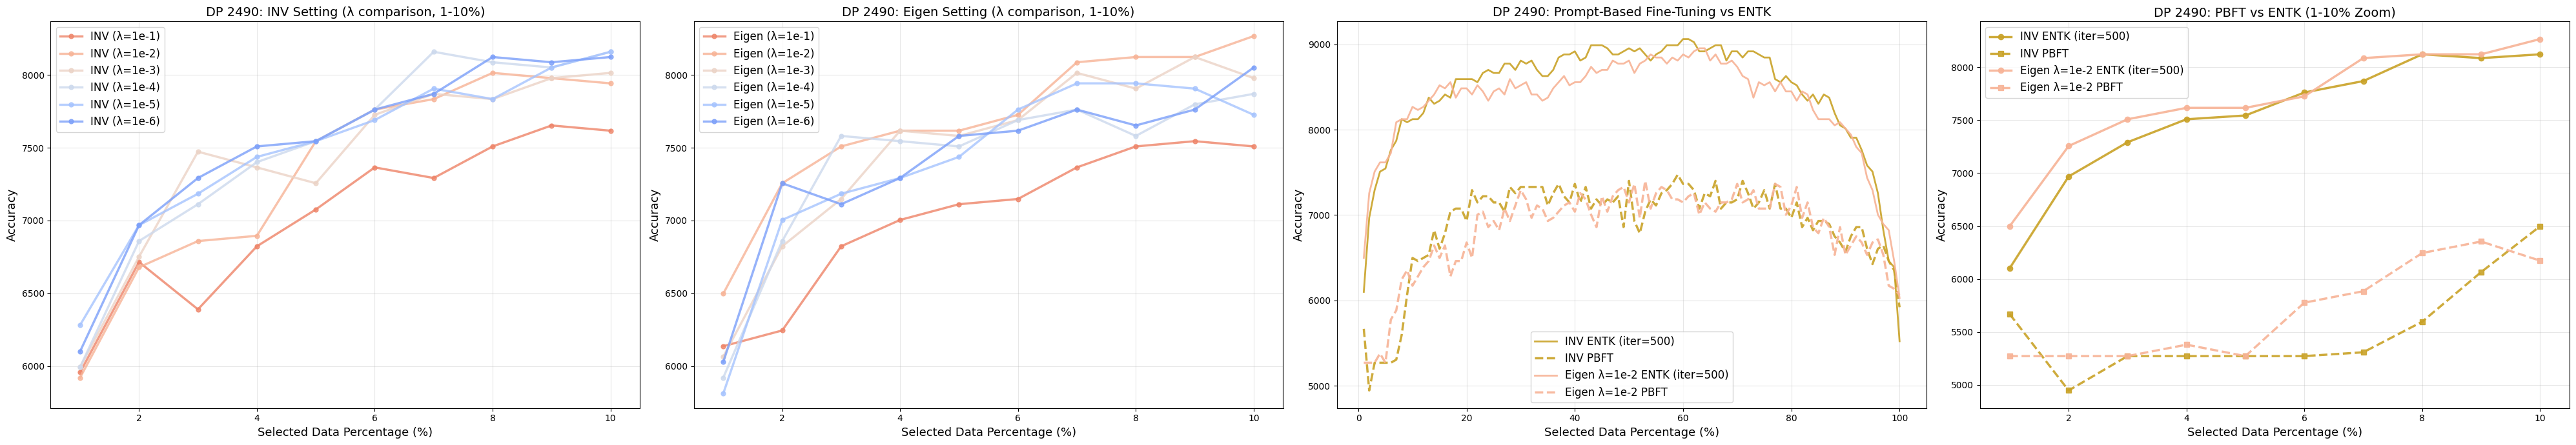

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2490
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6     = [6101, 6968, 7292, 7509, 7545, 7762, 7870, 8123, 8087, 8123, 8123, 8195, 8375, 8303, 8339, 8412, 8375, 8592, 8592, 8592, 8592, 8556, 8664, 8700, 8664, 8664, 8773, 8773, 8700, 8809, 8773, 8809, 8700, 8628, 8628, 8700, 8845, 8881, 8881, 8917, 8809, 8845, 8989, 8989, 8989, 8953, 8881, 8881, 8917, 8953, 8917, 8953, 8881, 8809, 8881, 8917, 8989, 8989, 8989, 9061, 9061, 9025, 8917, 8917, 8953, 8989, 8989, 8809, 8917, 8917, 8845, 8917, 8917, 8881, 8845, 8845, 8592, 8556, 8628, 8556, 8520, 8412, 8339, 8412, 8303, 8412, 8375, 8195, 8051, 8014, 7906, 7906, 7762, 7581, 7509, 7256, 6823, 6462, 6390, 5523]
inv_lam1e_5     = [6282, 6968, 7184, 7437, 7545, 7690, 7906, 7834, 8051, 8159, 8267, 8303, 8267, 8375, 8412, 8484, 8448, 8412, 8556, 8556, 8556, 8736, 8664, 8628, 8845, 8809, 8845, 8773, 8809, 8845, 8845, 8773, 8773, 8809, 8773, 8809, 8845, 8809, 8845, 8809, 8845, 8917, 8953, 8953, 8953, 8953, 8881, 8989, 8989, 8989, 8917, 8881, 8953, 8881, 8989, 8989, 8989, 9025, 9061, 9097, 9097, 9097, 9025, 8953, 8989, 8917, 9025, 8881, 8881, 8809, 8917, 8953, 8917, 8845, 8881, 8809, 8700, 8628, 8484, 8592, 8484, 8448, 8303, 8303, 8339, 8267, 8303, 8123, 8087, 7978, 7978, 7834, 7798, 7581, 7473, 7329, 6895, 6462, 6390, 5523]  
inv_lam1e_4     = [5993, 6859, 7112, 7401, 7545, 7762, 8159, 8087, 8051, 8159, 8159, 8087, 8267, 8448, 8484, 8375, 8448, 8303, 8592, 8556, 8556, 8556, 8700, 8773, 8773, 8628, 8664, 8700, 8845, 8809, 8809, 8773, 8700, 8700, 8736, 8773, 8809, 8773, 8845, 8881, 8917, 8917, 8881, 8845, 8917, 8917, 8881, 8845, 8917, 8917, 8881, 9025, 8989, 8989, 9025, 8989, 8989, 8953, 9025, 9134, 9061, 8881, 8953, 8989, 9025, 8989, 9025, 8953, 8881, 8917, 8845, 8953, 8917, 8845, 8989, 8736, 8628, 8592, 8556, 8520, 8375, 8375, 8267, 8195, 8231, 8231, 8123, 8123, 8159, 8014, 7906, 7870, 7834, 7581, 7509, 7401, 6787, 6354, 6245, 5523]         
inv_lam1e_3     = [5993, 6751, 7473, 7365, 7256, 7726, 7870, 7834, 7978, 8014, 8087, 8195, 8051, 8231, 8231, 8303, 8267, 8375, 8412, 8412, 8484, 8556, 8448, 8664, 8664, 8700, 8664, 8664, 8628, 8736, 8736, 8664, 8736, 8773, 8664, 8700, 8700, 8736, 8809, 8809, 8700, 8628, 8664, 8736, 8881, 8773, 8845, 8773, 8881, 8917, 8917, 8881, 8917, 9025, 9025, 8989, 9097, 9097, 9061, 9025, 9025, 9134, 9134, 9097, 8989, 8953, 8953, 8989, 9025, 9061, 9025, 8989, 8881, 8809, 8664, 8664, 8700, 8628, 8628, 8592, 8520, 8520, 8412, 8448, 8412, 8303, 8267, 8195, 8051, 7834, 7690, 7726, 7653, 7545, 7581, 7292, 6823, 6534, 6318, 5596]
inv_lam1e_2     = [5921, 6679, 6859, 6895, 7545, 7762, 7834, 8014, 7978, 7942, 7978, 8123, 8123, 8123, 8087, 8195, 8267, 8267, 8231, 8412, 8339, 8375, 8267, 8556, 8556, 8520, 8520, 8592, 8556, 8700, 8773, 8809, 8809, 8845, 8845, 8773, 8809, 8845, 8845, 8845, 8809, 8845, 8881, 8881, 8881, 8809, 8809, 8845, 8845, 8917, 8917, 8953, 8989, 8989, 8989, 8953, 8845, 8917, 8953, 9061, 8989, 9025, 8953, 8917, 8953, 8881, 8845, 8881, 8917, 8845, 8917, 8881, 8809, 8773, 8664, 8736, 8736, 8592, 8520, 8520, 8448, 8448, 8484, 8412, 8448, 8195, 8195, 8195, 8231, 8123, 7906, 7834, 7726, 7726, 7473, 7292, 6895, 6606, 6245, 5704] 
inv_lam1e_1     = [5957, 6715, 6390, 6823, 7076, 7365, 7292, 7509, 7653, 7617, 7653, 7545, 7762, 7906, 8051, 7870, 7978, 7870, 8014, 8159, 8267, 8159, 8267, 8412, 8484, 8520, 8484, 8484, 8592, 8556, 8520, 8700, 8664, 8700, 8664, 8664, 8664, 8628, 8628, 8700, 8628, 8664, 8736, 8700, 8700, 8773, 8773, 8736, 8809, 8700, 8736, 8809, 8809, 8809, 8773, 8809, 8881, 8845, 8881, 8809, 8773, 8809, 8845, 8700, 8736, 8809, 8845, 8845, 8773, 8700, 8664, 8592, 8592, 8556, 8700, 8809, 8628, 8628, 8664, 8520, 8484, 8412, 8303, 8303, 8195, 8123, 8123, 7978, 7978, 7834, 7762, 7762, 7617, 7437, 7329, 7112, 7004, 6715, 6498, 5740]
eigen_lam1e_6   = [6029, 7256, 7112, 7292, 7581, 7617, 7762, 7653, 7762, 8051, 8051, 8014, 7978, 7906, 7690, 7726, 7798, 7762, 7617, 7870, 7942, 7870, 7834, 7653, 7726, 7329, 7365, 7076, 6751, 6137, 6787, 7292, 7653, 8087, 7798, 7870, 8051, 8051, 8412, 8375, 8520, 8700, 8520, 8520, 8628, 8700, 8736, 8628, 8592, 8700, 8664, 8520, 8484, 8556, 8484, 8484, 8520, 8448, 8375, 8339, 8448, 8448, 8339, 8448, 8592, 8628, 8664, 8628, 8664, 8592, 8700, 8520, 8556, 8484, 8375, 8412, 8448, 8339, 8375, 8448, 8303, 8267, 8339, 8123, 8267, 8159, 7978, 8014, 7762, 7690, 7617, 7509, 7545, 7473, 7329, 7292, 7040, 6787, 6498, 6065]
eigen_lam1e_5   = [5812, 7004, 7184, 7292, 7437, 7762, 7942, 7942, 7906, 7726, 7906, 8087, 7978, 7834, 8123, 7906, 7690, 7762, 8014, 8014, 8014, 7653, 7365, 7509, 7437, 7581, 7437, 7148, 6895, 6354, 6498, 6859, 7076, 7509, 7726, 8195, 8123, 8231, 8267, 8556, 8375, 8809, 8592, 8484, 8628, 8628, 8412, 8412, 8484, 8592, 8736, 8773, 8664, 8556, 8592, 8520, 8592, 8700, 8664, 8700, 8592, 8556, 8556, 8628, 8520, 8556, 8556, 8592, 8339, 8412, 8556, 8375, 8412, 8448, 8556, 8520, 8375, 8448, 8339, 8375, 8375, 8303, 8159, 8195, 8159, 8087, 7906, 7978, 7762, 7690, 7653, 7581, 7509, 7401, 7365, 7148, 6931, 6715, 6390, 6065]
eigen_lam1e_4   = [5921, 6859, 7581, 7545, 7509, 7690, 7762, 7581, 7798, 7870, 8123, 7798, 7870, 7762, 7762, 7798, 7870, 7798, 7834, 7653, 8123, 7906, 7870, 7942, 7726, 7762, 7653, 7148, 6679, 6643, 6787, 7040, 7437, 7581, 7978, 8014, 7978, 7906, 8051, 8123, 8087, 8412, 8339, 8448, 8628, 8484, 8484, 8592, 8773, 8773, 8664, 8773, 8664, 8484, 8700, 8556, 8556, 8736, 8628, 8628, 8700, 8628, 8628, 8556, 8520, 8448, 8520, 8484, 8412, 8484, 8484, 8484, 8520, 8303, 8303, 8339, 8267, 8339, 8159, 8303, 8231, 8303, 8231, 7978, 8123, 8303, 8267, 7978, 7978, 7942, 7726, 7653, 7545, 7365, 7220, 7220, 6931, 6787, 6498, 6065]
eigen_lam1e_3   = [6065, 6823, 7148, 7617, 7581, 7690, 8014, 7906, 8123, 7978, 8267, 8087, 7942, 8087, 8267, 8375, 8339, 8303, 8195, 8412, 8339, 8123, 8448, 8448, 8484, 7978, 8195, 7942, 8014, 8123, 7978, 8051, 8123, 8195, 8267, 8303, 8375, 8448, 8448, 8375, 8375, 8448, 8448, 8339, 8520, 8556, 8520, 8628, 8592, 8628, 8556, 8664, 8736, 8700, 8520, 8412, 8556, 8736, 8700, 8736, 8664, 8773, 8773, 8845, 8809, 8773, 8881, 8845, 8881, 8773, 8736, 8700, 8664, 8700, 8628, 8592, 8592, 8520, 8339, 8520, 8339, 8195, 8231, 8267, 8267, 8159, 8051, 7978, 7906, 7798, 7690, 7617, 7509, 7509, 7292, 7184, 6859, 6715, 6498, 6065]
eigen_lam1e_2   = [6498, 7256, 7509, 7617, 7617, 7726, 8087, 8123, 8123, 8267, 8231, 8267, 8339, 8412, 8520, 8484, 8556, 8375, 8484, 8484, 8412, 8520, 8448, 8339, 8448, 8484, 8412, 8592, 8484, 8520, 8556, 8412, 8412, 8339, 8375, 8484, 8556, 8628, 8520, 8556, 8556, 8628, 8736, 8664, 8700, 8700, 8809, 8773, 8773, 8809, 8664, 8773, 8809, 8881, 8845, 8845, 8773, 8845, 8809, 8881, 8845, 8917, 8953, 8953, 8809, 8881, 8773, 8773, 8809, 8736, 8628, 8592, 8375, 8556, 8520, 8556, 8448, 8556, 8448, 8448, 8339, 8448, 8412, 8231, 8123, 8123, 8123, 8051, 8087, 8014, 7942, 7798, 7726, 7437, 7292, 7004, 6895, 6823, 6462, 6029]
eigen_lam1e_1   = [6137, 6245, 6823, 7004, 7112, 7148, 7365, 7509, 7545, 7509, 7509, 7798, 7762, 7726, 7834, 7798, 7870, 7870, 7906, 8051, 8014, 8087, 8051, 8123, 8267, 8303, 8267, 8087, 8159, 8123, 8123, 8339, 8339, 8448, 8484, 8484, 8412, 8448, 8484, 8484, 8592, 8484, 8448, 8520, 8484, 8628, 8628, 8556, 8700, 8664, 8773, 8736, 8736, 8700, 8700, 8592, 8700, 8628, 8628, 8736, 8736, 8700, 8700, 8664, 8664, 8736, 8628, 8773, 8664, 8773, 8700, 8556, 8628, 8556, 8520, 8556, 8412, 8267, 8195, 8159, 8159, 8087, 8087, 8051, 8014, 8087, 7978, 8014, 7906, 7834, 7762, 7617, 7401, 7220, 7148, 7148, 6931, 6715, 6498, 6101]

# Prediction with random shapley values
r_inv_lam1e_6   = [5199, 5451, 5379, 5668, 5451, 5632, 5668, 5993, 5740, 5848, 5993, 5884, 6137, 5993, 5921, 5596, 5776, 5957, 5957, 5812, 5812, 5740, 5704, 5632, 5812, 5704, 5704, 5740, 5848, 5668, 5848, 5596, 5704, 5740, 5379, 5560, 5596, 5632, 5560, 5632, 5668, 5415, 5487, 5451, 5487, 5560, 5415, 5487, 5560, 5523, 5632, 5812, 5884, 5776, 5740, 5740, 5812, 5704, 5704, 5848, 5776, 5776, 5848, 5921, 5776, 5812, 6137, 6065, 6101, 6137, 6065, 5993, 6101, 6065, 6065, 6029, 5993, 5993, 5921, 5957, 6029, 5957, 5957, 5776, 5776, 5812, 5884, 5884, 5812, 5921, 5776, 5812, 5848, 5632, 5632, 5704, 5379, 5451, 5451, 5523]
r_inv_lam1e_5   = [5199, 5451, 5379, 5668, 5451, 5632, 5668, 5993, 5740, 5848, 5993, 5884, 6137, 5993, 5921, 5596, 5776, 5957, 5957, 5812, 5812, 5740, 5704, 5632, 5812, 5704, 5704, 5740, 5848, 5668, 5848, 5596, 5704, 5740, 5379, 5560, 5596, 5632, 5560, 5632, 5668, 5415, 5487, 5451, 5487, 5560, 5415, 5487, 5560, 5523, 5632, 5812, 5884, 5776, 5740, 5740, 5812, 5704, 5704, 5848, 5776, 5776, 5848, 5921, 5776, 5812, 6137, 6065, 6101, 6137, 6065, 5993, 6101, 6065, 6065, 6029, 5993, 5993, 5921, 5957, 6029, 5957, 5957, 5776, 5776, 5812, 5884, 5884, 5812, 5921, 5776, 5812, 5848, 5632, 5632, 5704, 5415, 5451, 5451, 5523]  
r_inv_lam1e_4   = [5199, 5451, 5379, 5668, 5451, 5632, 5668, 5993, 5740, 5848, 5993, 5884, 6137, 5993, 5921, 5596, 5776, 5957, 5957, 5812, 5812, 5740, 5704, 5632, 5812, 5704, 5704, 5740, 5848, 5668, 5848, 5596, 5704, 5740, 5379, 5560, 5596, 5632, 5560, 5632, 5668, 5415, 5487, 5451, 5487, 5560, 5415, 5487, 5560, 5523, 5632, 5812, 5884, 5776, 5740, 5740, 5812, 5704, 5740, 5848, 5776, 5776, 5848, 5921, 5740, 5812, 6137, 6065, 6101, 6137, 6101, 5993, 6065, 6065, 6065, 6029, 5993, 5993, 5921, 5957, 5993, 5957, 5957, 5776, 5740, 5812, 5884, 5884, 5848, 5921, 5776, 5776, 5812, 5596, 5632, 5668, 5415, 5415, 5451, 5523] 
r_inv_lam1e_3   = [5199, 5451, 5379, 5668, 5451, 5632, 5668, 5993, 5740, 5848, 5993, 5884, 6173, 5957, 5921, 5632, 5776, 5884, 5957, 5812, 5776, 5740, 5704, 5596, 5848, 5704, 5740, 5740, 5848, 5668, 5848, 5596, 5704, 5704, 5379, 5560, 5632, 5668, 5560, 5632, 5668, 5415, 5487, 5451, 5451, 5596, 5415, 5487, 5560, 5487, 5632, 5848, 5921, 5776, 5812, 5776, 5884, 5632, 5740, 5848, 5848, 5776, 5812, 5921, 5776, 5776, 6101, 6065, 6101, 6137, 6173, 6101, 6101, 6029, 6029, 6101, 5993, 5921, 5957, 5957, 5957, 5884, 5884, 5740, 5776, 5848, 5848, 5812, 5848, 5957, 5776, 5812, 5776, 5668, 5596, 5668, 5451, 5451, 5523, 5596]  
r_inv_lam1e_2   = [5199, 5487, 5451, 5668, 5451, 5668, 5632, 5993, 5848, 5921, 6029, 5884, 6173, 5957, 5957, 5812, 5812, 5812, 5957, 5776, 5740, 5704, 5812, 5560, 5848, 5812, 5848, 5776, 5957, 5632, 5884, 5632, 5812, 5776, 5523, 5596, 5704, 5632, 5560, 5632, 5668, 5415, 5632, 5596, 5487, 5632, 5415, 5451, 5668, 5451, 5668, 5740, 5884, 5812, 5848, 5812, 5993, 5812, 5740, 5812, 5848, 5812, 5848, 5884, 5884, 5776, 6101, 6029, 5993, 6209, 6173, 6137, 6101, 6029, 6065, 6137, 6101, 5921, 6029, 6065, 6209, 6209, 6065, 5812, 5921, 5884, 5921, 5740, 5776, 5921, 5812, 5704, 5848, 5596, 5668, 5704, 5740, 5596, 5668, 5704]   
r_inv_lam1e_1   = [5054, 5415, 5379, 5812, 5523, 5668, 5632, 6354, 5884, 5993, 6065, 5848, 6101, 6029, 5884, 5776, 5740, 5812, 5993, 5884, 5884, 6137, 6029, 5812, 5884, 6209, 5993, 6101, 6101, 5993, 5957, 5884, 5740, 6029, 5993, 5921, 5812, 5704, 5812, 5740, 5704, 5487, 5632, 5704, 5668, 5704, 5704, 5740, 5884, 5812, 5776, 5884, 5957, 5740, 5921, 5957, 6209, 6029, 6029, 6029, 5957, 6065, 6209, 6209, 6173, 6137, 6173, 6137, 6245, 6209, 6282, 6245, 6282, 6137, 6245, 6426, 6245, 6282, 6282, 6354, 6282, 6318, 6282, 6209, 5993, 6065, 6101, 6173, 6065, 5993, 5776, 5776, 5921, 5668, 5776, 5740, 5848, 5848, 5812, 5740] 
r_eigen_lam1e_6 = [5199, 5379, 5307, 5271, 5054, 5343, 5451, 5487, 5415, 5632, 5668, 5740, 5740, 5343, 4874, 4910, 4729, 4874, 4729, 4729, 5018, 5054, 5090, 5054, 5235, 5487, 5451, 5199, 4874, 4477, 5018, 4910, 4946, 5487, 5596, 5271, 5162, 5451, 5090, 5162, 5162, 5379, 5451, 5235, 5307, 5415, 5523, 5704, 5596, 5776, 5668, 5776, 5921, 5848, 5957, 5993, 5921, 5848, 5957, 6101, 6101, 5993, 6137, 6209, 6173, 6209, 6390, 6498, 6354, 6498, 6426, 6570, 6498, 6426, 6282, 6462, 6390, 6354, 6318, 6137, 6318, 6318, 6426, 6354, 6209, 6209, 6101, 6173, 6137, 6101, 6245, 5957, 5740, 5921, 5957, 5957, 6137, 6101, 6245, 6065]
r_eigen_lam1e_5 = [5235, 5451, 5235, 5235, 5054, 5271, 5487, 5523, 5379, 5632, 5848, 5776, 5812, 5451, 4910, 4838, 4693, 4874, 4729, 4729, 4982, 5090, 5199, 5054, 5235, 5415, 5451, 5235, 4874, 4693, 5235, 4982, 4910, 5451, 5596, 5271, 5162, 5415, 5090, 5162, 5162, 5379, 5451, 5235, 5307, 5415, 5523, 5704, 5596, 5776, 5704, 5776, 5921, 5848, 5957, 5993, 5921, 5848, 5957, 6101, 6101, 5993, 6137, 6209, 6173, 6209, 6390, 6498, 6354, 6498, 6426, 6570, 6498, 6426, 6282, 6462, 6390, 6354, 6318, 6137, 6318, 6318, 6426, 6354, 6209, 6209, 6101, 6173, 6137, 6101, 6245, 5957, 5740, 5921, 5957, 5957, 6137, 6101, 6245, 6065]
r_eigen_lam1e_4 = [5199, 5451, 5235, 5235, 5018, 5271, 5451, 5487, 5415, 5632, 5848, 5776, 5812, 5451, 4910, 4838, 4621, 4874, 4765, 4693, 4982, 5126, 5199, 5018, 5379, 5415, 5343, 5271, 5126, 5199, 5271, 4946, 5054, 5379, 5487, 5307, 5162, 5343, 5126, 5235, 5199, 5451, 5451, 5199, 5379, 5415, 5560, 5704, 5596, 5740, 5704, 5776, 5921, 5848, 5957, 5957, 5921, 5848, 5957, 6101, 6101, 5993, 6137, 6209, 6173, 6209, 6354, 6498, 6318, 6534, 6426, 6570, 6534, 6426, 6282, 6462, 6390, 6354, 6318, 6137, 6318, 6318, 6426, 6354, 6209, 6209, 6101, 6209, 6137, 6101, 6245, 5957, 5740, 5921, 5957, 5957, 6137, 6101, 6245, 6065]
r_eigen_lam1e_3 = [5199, 5451, 5235, 5235, 5090, 5307, 5487, 5487, 5451, 5632, 5848, 5812, 5848, 5487, 4910, 4801, 4693, 4801, 4765, 4801, 4874, 5054, 5090, 5126, 5162, 5235, 5271, 5271, 5343, 5343, 5487, 5523, 5379, 5560, 5523, 5126, 5126, 5307, 5199, 5271, 5307, 5596, 5451, 5271, 5307, 5307, 5596, 5776, 5596, 5812, 5668, 5776, 5921, 5921, 6029, 5993, 5957, 5848, 5921, 6065, 6101, 6065, 6173, 6137, 6065, 6173, 6354, 6390, 6318, 6498, 6426, 6534, 6462, 6426, 6282, 6498, 6318, 6354, 6354, 6137, 6282, 6318, 6426, 6245, 6209, 6173, 6101, 6209, 6137, 6101, 6245, 5957, 5740, 5957, 5957, 5957, 6137, 6101, 6245, 6065]
r_eigen_lam1e_2 = [5199, 5523, 5235, 5343, 5199, 5451, 5487, 5704, 5560, 5740, 5921, 5848, 6101, 5560, 5307, 4838, 4693, 4838, 4838, 4910, 4910, 5126, 5090, 5126, 5162, 5090, 5271, 5415, 5379, 5199, 5415, 5451, 5379, 5415, 5451, 5560, 5704, 5740, 5668, 5596, 5523, 5632, 5632, 5415, 5307, 5415, 5668, 5704, 5776, 5704, 5523, 5740, 5993, 5848, 6065, 6065, 6101, 5993, 5884, 6065, 6065, 6029, 6245, 6245, 6137, 6173, 6282, 6426, 6245, 6534, 6498, 6498, 6534, 6462, 6390, 6462, 6354, 6318, 6354, 6209, 6282, 6318, 6318, 6282, 6318, 6209, 6101, 6209, 6282, 6029, 6137, 5993, 5740, 5993, 5993, 5993, 6065, 6065, 6209, 6029]
r_eigen_lam1e_1 = [5271, 5487, 5487, 5632, 5523, 5560, 5668, 5993, 5921, 5993, 6029, 5957, 6065, 5921, 5812, 5668, 5668, 5451, 5451, 5523, 5523, 5740, 5415, 5523, 5993, 5884, 5884, 5921, 5704, 5668, 5704, 5848, 5957, 6029, 5884, 5957, 6029, 5993, 5848, 5668, 5560, 5812, 5776, 5632, 5740, 5921, 5957, 5993, 5957, 5884, 5884, 6065, 6209, 6137, 6173, 6209, 6209, 6137, 6173, 6245, 6209, 6318, 6209, 6354, 6173, 6209, 6498, 6498, 6462, 6570, 6534, 6462, 6498, 6643, 6462, 6462, 6426, 6390, 6426, 6354, 6390, 6209, 6282, 6390, 6390, 6209, 6173, 6209, 5993, 6209, 6245, 6101, 6065, 6029, 6029, 5993, 6029, 6101, 6282, 6101]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [5668, 4946, 5271, 5271, 5271, 5271, 5307, 5596, 6065, 6498, 6462, 6498, 6534, 6823, 6606, 6787, 7040, 7076, 7076, 6931, 7292, 7148, 7220, 7220, 7148, 7148, 7040, 7329, 7256, 7329, 7329, 7329, 7329, 7329, 7112, 7256, 7365, 7220, 7148, 7365, 7148, 7329, 7076, 7184, 7112, 7184, 7148, 7220, 6859, 7401, 6931, 6787, 7040, 7184, 7112, 7256, 7292, 7365, 7473, 7365, 7365, 7292, 7076, 7256, 7220, 7401, 7076, 7148, 7148, 7184, 7401, 7256, 7076, 7148, 7292, 7076, 7365, 7076, 7076, 6968, 7148, 6859, 6968, 6823, 6931, 6931, 6895, 6751, 6679, 6570, 6751, 6859, 6859, 6606, 6426, 6606, 6643, 6462, 6354, 5921]
pbft_eigen_lam1e_2 = [5271, 5271, 5271, 5379, 5271, 5776, 5884, 6245, 6354, 6173, 6282, 6390, 6462, 6643, 6498, 6643, 6282, 6462, 6462, 6679, 6498, 7004, 7040, 6859, 6931, 6823, 7076, 6931, 7112, 7292, 7184, 6968, 7112, 7076, 6931, 6968, 7040, 7112, 7148, 7040, 7256, 7184, 7004, 6859, 7220, 7040, 7220, 7292, 7329, 7148, 7365, 6968, 7401, 7076, 7256, 7329, 7292, 7184, 7184, 7148, 7220, 7256, 7004, 7148, 7076, 7040, 7148, 7148, 7184, 7365, 7148, 7184, 7292, 7076, 7076, 7076, 7365, 7329, 7004, 7112, 7329, 6968, 7148, 6859, 6787, 6968, 6859, 6534, 6859, 6534, 6643, 6751, 6679, 6534, 6679, 6715, 6534, 6173, 6137, 6065]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

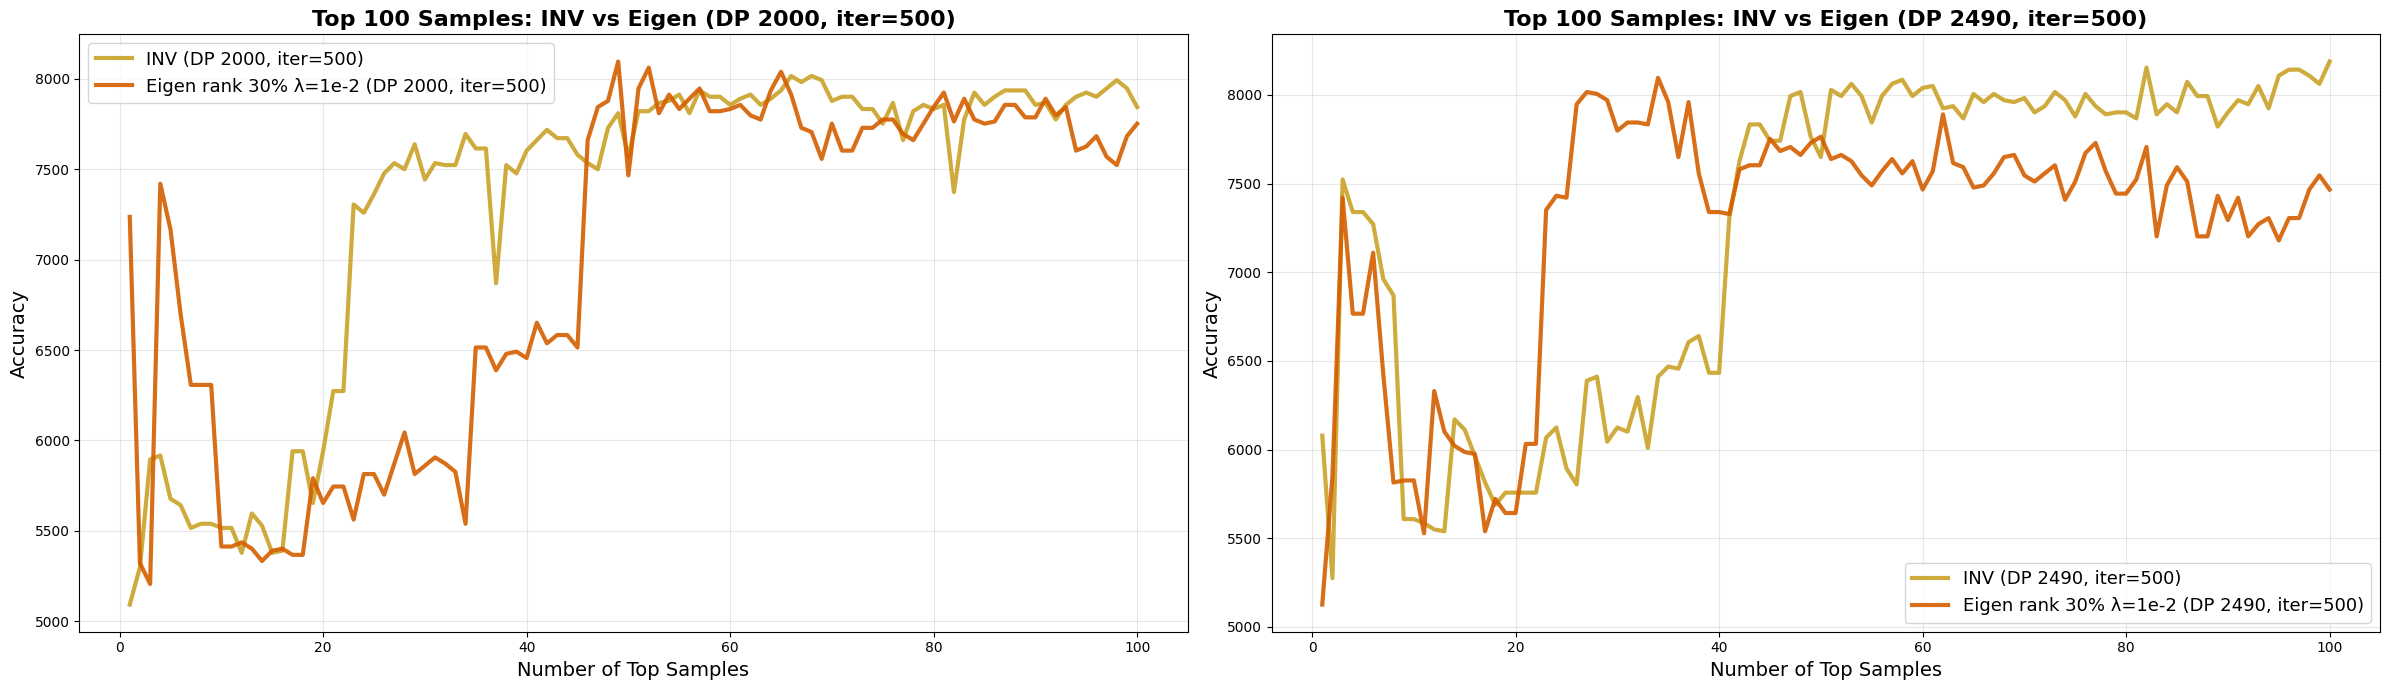

In [ ]:
# top 100 data
data = [i for i in range(1, 101)]

inv_2000               = 
eigen_2000_30_lam1e_2  = 

inv_2490               = 
eigen_2490_30_lam1e_2  = 

# Create (1,2) subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

# Color settings
inv_color = '#C9A227'
eigen_color = '#D55E00'  # Orange-red for eigen

# ===== Subplot (1,1): DP 2000 =====
ax_2000 = axes[0]

# Plot INV data (num_dp=2000)
ax_2000.plot(data, inv_2000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2000, rank=30%, lambda=1e-2)
ax_2000.plot(data, eigen_2000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2000, iter=500)', alpha=0.9)

ax_2000.set_xlabel('Number of Top Samples', fontsize=14)
ax_2000.set_ylabel('Accuracy', fontsize=14)
ax_2000.set_title('Top 100 Samples: INV vs Eigen (DP 2000, iter=500)', fontsize=16, fontweight='bold')
ax_2000.legend(fontsize=13, loc='best')
ax_2000.grid(True, alpha=0.3)

# ===== Subplot (1,2): DP 2490 =====
ax_2490 = axes[1]

# Plot INV data (num_dp=2490)
ax_2490.plot(data, inv_2490, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2490, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2490, rank=30%, lambda=1e-2)
ax_2490.plot(data, eigen_2490_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2490, iter=500)', alpha=0.9)

ax_2490.set_xlabel('Number of Top Samples', fontsize=14)
ax_2490.set_ylabel('Accuracy', fontsize=14)
ax_2490.set_title('Top 100 Samples: INV vs Eigen (DP 2490, iter=500)', fontsize=16, fontweight='bold')
ax_2490.legend(fontsize=13, loc='best')
ax_2490.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()